In [267]:
import numpy as np
import pandas as pd

In [268]:
data = pd.read_csv('spam.csv' , encoding='latin-1')

In [269]:
data.sample(10)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4289,ham,"For you information, IKEA is spelled with all ...",NaN,NaN,NaN
3937,ham,WHEN THE FIRST STRIKE IS A RED ONE. THE BIRD +...,NaN,NaN,NaN
1035,ham,"Hello baby, did you get back to your mom's ? A...",NaN,NaN,NaN
2976,ham,"Ok omw now, you at castor?",NaN,NaN,NaN
3198,ham,No de.am seeing in online shop so that i asked.,NaN,NaN,NaN
4459,ham,This is wishing you a great day. Moji told me ...,NaN,NaN,NaN
467,ham,When are you going to ride your bike?,NaN,NaN,NaN
4599,ham,Hi did u decide wot 2 get 4 his bday if not il...,NaN,NaN,NaN
847,ham,I am in office:)whats the matter..msg me now.i...,NaN,NaN,NaN
4056,ham,Noice. Text me when you're here,NaN,NaN,NaN


In [270]:
data.shape

(5572, 5)

In [271]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model buitding
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [272]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [273]:
# drop last 3 cols
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [274]:
# Renaming the columns 
data.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [275]:
data.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [276]:
# converting target labels(categorical) to binary values (numerical) by label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data['target']=encoder.fit_transform(data['target'])


In [277]:
# missing values
data.isnull().sum()

target    0
text      0
dtype: int64

In [278]:
# checking for duplicate values
data.duplicated().sum()

np.int64(403)

In [279]:
# remove duplicate values
data = data.drop_duplicates(keep='first')

In [280]:
data.shape

(5169, 2)

## 2. EDA (Exploratory Data Analysis)

In [281]:
data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [282]:
data['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [283]:
import matplotlib.pyplot as plt

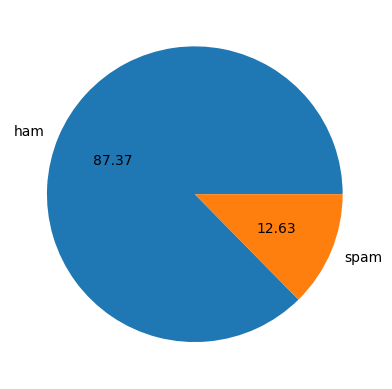

In [284]:
plt.pie(data['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [285]:
# Data is imbalanced
# spam are less than ham.

In [286]:
import nltk # nltk is natural language toolkit . It's a famous NLP library in python

In [287]:
nltk.download('punkt') # punkt is a pre-trained model which helps in tokenization
nltk.download('punkt_tab') # punkt_tab is a tab-separated version of the punkt model

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tapasya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tapasya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [288]:
data['num_characters']=data['text'].apply(len)
data.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [289]:
# number of words 
data['num_words']=data['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [290]:
data.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [291]:
data['num_sentences']=data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [292]:
data.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [293]:
data[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [294]:
# ham
data[data['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [295]:
#spam
data[data['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [296]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

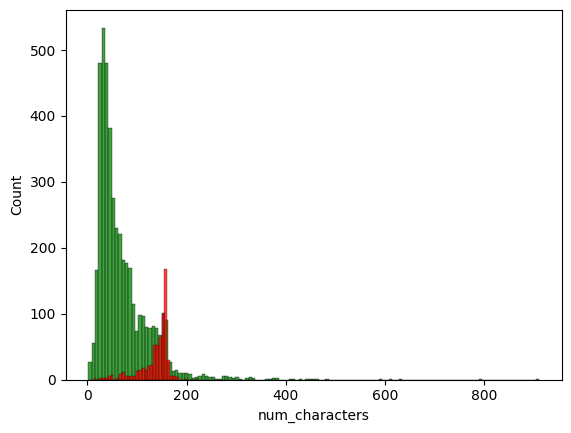

In [297]:
plt.Figure(figsize=(12,8))
sns.histplot(data[data['target']==0].num_characters,color='green')
sns.histplot(data[data['target']==1].num_characters,color='red')

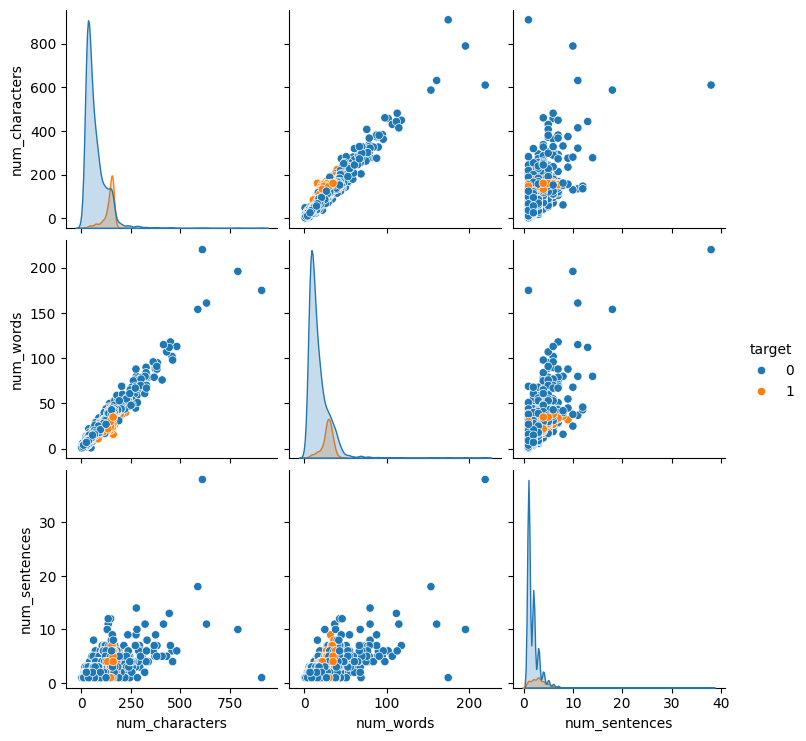

In [298]:
sns.pairplot(data,hue='target')

In [299]:
data[['target','num_characters','num_words', 'num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

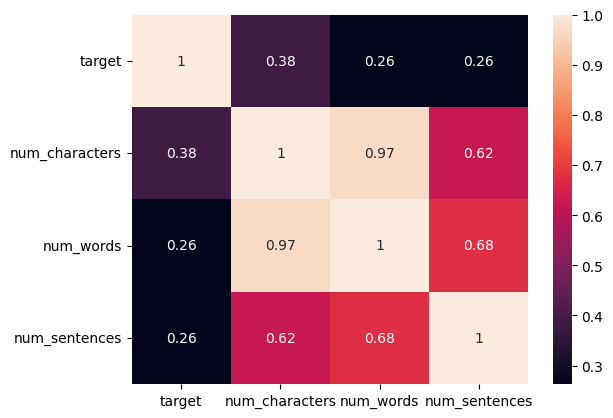

In [300]:
sns.heatmap(data[['target','num_characters','num_words', 'num_sentences']].corr(), annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [301]:
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tapasya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [302]:


def transform_text(text):
    text=text.lower() # Lower case
    text=nltk.word_tokenize(text) # Tokenization

    y = []
    for i in text :
        if i.isalnum(): # Removing special characters
            y.append(i)
    text = y[:]
    y.clear()
    # Removing stop words and punctuation
    for i in text:
        if i not  in stopwords.words('english') and i not in string.punctuation:
            y.append(i)  

    # Stemming        
    text = y[:]
    y.clear()
    ps = nltk.PorterStemmer()
    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [303]:
data['transformed_text'] = data['text'].apply(transform_text)

In [304]:
# transform_text('Hello World! This is a test message.') ---> lower case --- 'hello world! this is a test message.'
# transform_text('Hello World! This is a test message.') ---> tokenized --- ['hello', 'world', 'this', 'is', 'a', 'test', 'message']
# transform_text('Hello World! @@ This is a test message.&&&&&&&  ') ---> ['hello', 'world', 'this', 'is', 'a', 'test', 'message']

#### **from nltk.corpus import stopwords**
#### **stopwords.words('english')**

**This will give you a list of all the stop words in the English language. You can use this list to remove stop words from your text data during preprocessing.Like i , me , we , they , us** 

#### **import string**
#### **string.punctuation**

 **like !@#$%^&*()-+**

In [305]:
# transform_text('Hi how Are you Nitish?') ---> ['hi', 'nitish']

In [306]:
# transform_text('Hi how Are you Nitish? dancing loving caring learning') ---> 'hi nitish danc love care learn'

#### Word Cloud for Spam Messages

In [307]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [308]:
spam_wc = wc.generate(data[data['target']==1]['transformed_text'].str.cat(sep=" "))

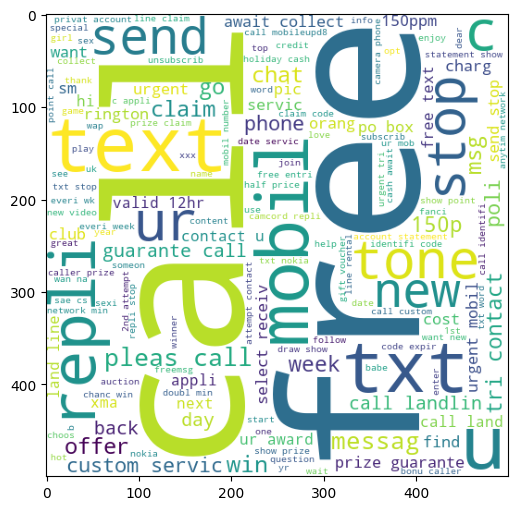

In [309]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

#### Word Cloud for ham Messages

In [310]:
ham_wc = wc.generate(data[data['target']==0]['transformed_text'].str.cat(sep=" "))

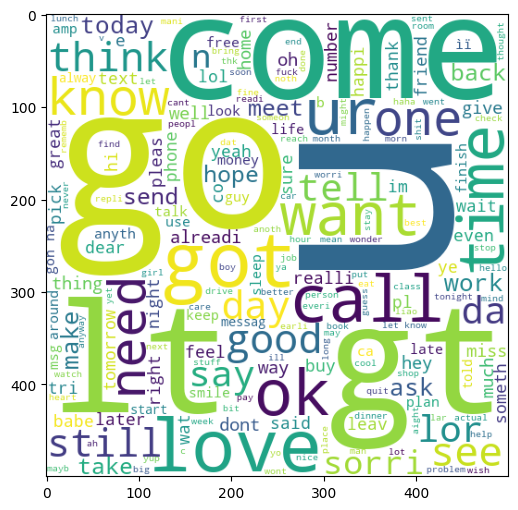

In [311]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [312]:
spam_corpus = []
for msg in data[data['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [313]:
len(spam_corpus)

9939

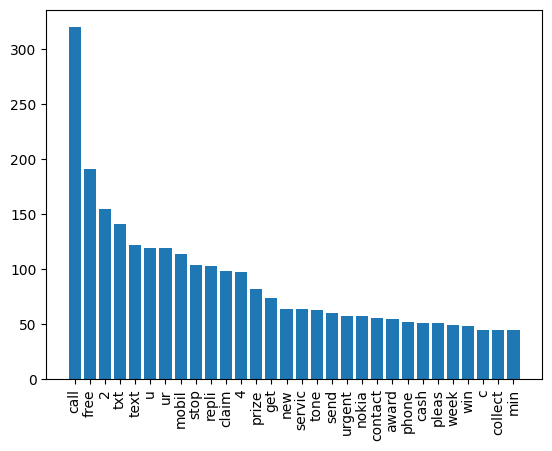

In [314]:
from collections import Counter
# FOR Spam Messages
df = pd.DataFrame(Counter(spam_corpus).most_common(30))
plt.bar(df[0], df[1])
plt.xticks(rotation='vertical')
plt.show()



In [315]:
ham_corpus = []
for msg in data[data['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

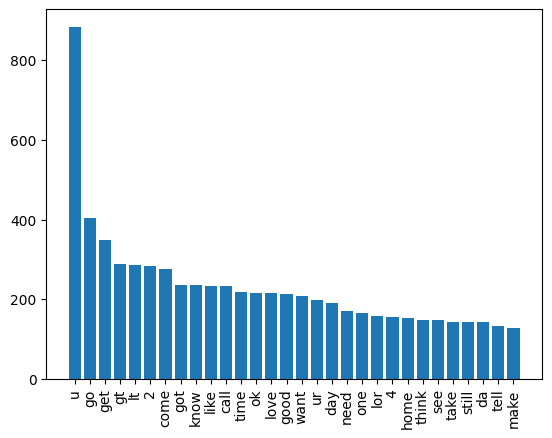

In [316]:
df2= pd.DataFrame(Counter(ham_corpus).most_common(30))
plt.bar(df2[0],df2[1])
plt.xticks(rotation='vertical')
plt.show()


In [317]:
len(ham_corpus)

35404

## 4. Model Building

In [318]:
# Text Vectorization
## using Bag of Words 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [319]:
X = tfidf.fit_transform(data['transformed_text']).toarray()

In [320]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [321]:
# appending the num_character col to X
#X = np.hstack((X,data['num_characters'].values.reshape(-1,1)))

In [322]:
X.shape

(5169, 3000)

In [323]:
y = data['target'].values

In [324]:
y.shape

(5169,)

In [325]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [326]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [327]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
accuracy1 = accuracy_score(y_test,y_pred1)
confusion1 = confusion_matrix(y_test,y_pred1)
precision1 = precision_score(y_test,y_pred1)



In [328]:
print("GaussianNB")
print("Accuracy:",accuracy1)    
print("Confusion Matrix:\n",confusion1)
print("Precision:",precision1)

GaussianNB
Accuracy: 0.8694390715667312
Confusion Matrix:
 [[788 108]
 [ 27 111]]
Precision: 0.5068493150684932


In [329]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
accuracy2 = accuracy_score(y_test,y_pred2)
confusion2 = confusion_matrix(y_test,y_pred2)
precision2 = precision_score(y_test,y_pred2)


In [330]:

print("\nMultinomialNB")
print(accuracy2)    
print(confusion2)
print(precision2)


MultinomialNB
0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [331]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
accuracy3 = accuracy_score(y_test,y_pred3)
confusion3 = confusion_matrix(y_test,y_pred3)
precision3 = precision_score(y_test,y_pred3)


In [332]:
print("TfidfVectorizer + BernoulliNB")
print("Accuracy:",accuracy3)    
print("Confusion Matrix:\n",confusion3)
print("Precision:",precision3)

TfidfVectorizer + BernoulliNB
Accuracy: 0.9835589941972921
Confusion Matrix:
 [[895   1]
 [ 16 122]]
Precision: 0.991869918699187


In [333]:
# here precision matters more than accuracy because we want to minimize false positives (i.e., classifying a legitimate message as spam).
#  A higher precision indicates that when the model predicts a message as spam, it is more likely to be correct.

# tfidf --> MNB gives precision of 1.0 which is the best model for this problem.


In [334]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [335]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [336]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'MNB': mnb,
    'DTC': dtc,
    'LRC': lrc,
    'RFC': rfc,
    'ABC': abc,
    'BC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'XGB': xgb
}

In [337]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [338]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [339]:
accuracy_scores = []
precision_scores = []
for name,clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)
    print("For ",name)
    print("Accuracy:",current_accuracy)
    print("Precision:",current_precision)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy: 0.9758220502901354
Precision: 0.9747899159663865
For  KN
Accuracy: 0.9052224371373307
Precision: 1.0
For  MNB
Accuracy: 0.9709864603481625
Precision: 1.0
For  DTC
Accuracy: 0.9294003868471954
Precision: 0.8282828282828283
For  LRC
Accuracy: 0.9584139264990329
Precision: 0.9702970297029703


C:\Users\Tapasya\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Tapasya\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RFC
Accuracy: 0.9758220502901354
Precision: 0.9829059829059829
For  ABC
Accuracy: 0.9245647969052224
Precision: 0.8488372093023255
For  BC
Accuracy: 0.9584139264990329
Precision: 0.8682170542635659
For  ETC
Accuracy: 0.9748549323017408
Precision: 0.9745762711864406
For  GBDT
Accuracy: 0.9468085106382979
Precision: 0.9191919191919192
For  XGB
Accuracy: 0.9671179883945842
Precision: 0.9482758620689655


In [340]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [341]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,MNB,0.970986,1.000000
5,RFC,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LRC,0.958414,0.970297
10,XGB,0.967118,0.948276
9,GBDT,0.946809,0.919192
7,BC,0.958414,0.868217
6,ABC,0.924565,0.848837


In [342]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [343]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,MNB,Accuracy,0.970986
2,RFC,Accuracy,0.975822
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LRC,Accuracy,0.958414
6,XGB,Accuracy,0.967118
7,GBDT,Accuracy,0.946809
8,BC,Accuracy,0.958414
9,ABC,Accuracy,0.924565


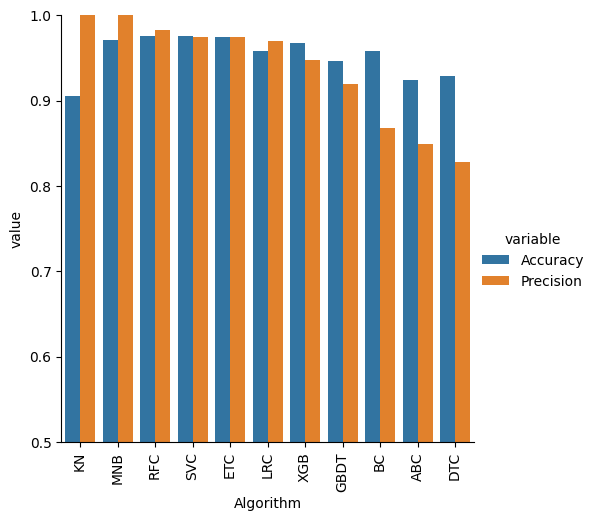

In [344]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [345]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [346]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [347]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [348]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [349]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [350]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [351]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,MNB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RFC,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LRC,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297
6,XGB,0.967118,0.948276,0.967118,0.948276,0.967118,0.948276,0.967118,0.948276
7,GBDT,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192
8,BC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,ABC,0.924565,0.848837,0.924565,0.848837,0.924565,0.848837,0.924565,0.848837


In [352]:
#Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [353]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [354]:
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [355]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(y_test, y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [356]:
#Applying stacking
estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

In [357]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)


In [358]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(y_test, y_pred))

Accuracy 0.9806576402321083
Precision 0.946969696969697


In [359]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(clf,open('model.pkl','wb'))
